# Regression Model - Part 2 - Early Stopping, Storing Weights, Plots per Horizon

## Steps:

### Data Preparation
* Loading pre-stored sequences


### Training
* Early Stopping
* Checkpoint
* Saving the models weights for further use

### Evaluation with Test Data
* Metrics per Horizon
* Plots per Horizon
* Overlay for specific time ranges
* Confidence Intervals



## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import joblib

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import torch
import torch.nn as nn

## Function definition

In [2]:
def train_val_test_split_by_date(data, train_end_date, val_end_date):
    """
    Split time series by specific dates.

    Parameters:
    -----------
    data : pandas DataFrame with DatetimeIndex
    train_end_date : str or datetime
        Last date for training set
    val_end_date : str or datetime
        Last date for validation set

    Returns:
    --------
    train, val, test : pandas DataFrame
    """
    train = data[:train_end_date]
    val = data[train_end_date:val_end_date]
    test = data[val_end_date:]

    return train, val, test


def split_features_target(data, target_column):
    """
    Split DataFrame into features (X) and target (y).

    Parameters:
    -----------
    data : pandas DataFrame
        The dataset to split
    target_column : str or list of str
        Name(s) of the target column(s)

    Returns:
    --------
    X : pandas DataFrame
        Features (all columns except target)
    y : pandas DataFrame or Series
        Target column(s)
    """
    if isinstance(target_column, str):
        # Single target column
        y = data[[target_column]]  # Keep as DataFrame
        X = data.drop(columns=[target_column])
    else:
        # Multiple target columns
        y = data[target_column]
        X = data.drop(columns=target_column)

    return X, y


def scale_data(X_train, X_val, X_test, y_train, y_val, y_test, method='standard'):
    """
    Scale data using only training set statistics.

    Parameters:
    -----------
    train, val, test : pandas DataFrame
    method : str
        'minmax' or 'standard'

    Returns:
    --------
    train_scaled, val_scaled, test_scaled, scaler
    """
    # Choose scaler
    if method == 'minmax':
        X_scaler = MinMaxScaler()
        y_scaler = MinMaxScaler()
    elif method == 'standard':
        X_scaler = StandardScaler()
        y_scaler = StandardScaler()
    else:
        raise ValueError("method must be 'minmax' or 'standard'")

    # Fit on X_train (keeping DataFrame structure)
    X_train_scaled = pd.DataFrame(
        X_scaler.fit_transform(X_train),
        index=X_train.index,
        columns=X_train.columns
    )

    X_val_scaled = pd.DataFrame(
        X_scaler.transform(X_val),
        index=X_val.index,
        columns=X_val.columns
    )

    X_test_scaled = pd.DataFrame(
        X_scaler.transform(X_test),
        index=X_test.index,
        columns=X_test.columns
    )

    # Fit on y_train (keeping DataFrame structure)
    y_train_scaled = pd.DataFrame(
        y_scaler.fit_transform(y_train),
        index=y_train.index,
        columns=y_train.columns
    )

    y_val_scaled = pd.DataFrame(
        y_scaler.transform(y_val),
        index=y_val.index,
        columns=y_val.columns
    )

    y_test_scaled = pd.DataFrame(
        y_scaler.transform(y_test),
        index=y_test.index,
        columns=y_test.columns
    )

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled, X_scaler, y_scaler


def inverse_scale(data, scaler):
    """
    Inverse transform scaled data back to original scale.

    Parameters:
    -----------
    data : numpy array or pandas DataFrame
        Scaled data
    scaler : sklearn scaler object
        Fitted scaler from scale_train_only()

    Returns:
    --------
    numpy array or pandas DataFrame in original scale
    """
    return scaler.inverse_transform(data)


def create_sequences(X_data, y_data, lookback, horizon):
    """
    Create sequences for multivariate multi-step time series forecasting.

    Parameters:
    -----------
    X_data : numpy array or pandas DataFrame
        Feature data (all input variables)
    y_data : numpy array or pandas DataFrame
        Target data (variable(s) to predict)
    lookback : int
        Number of past time steps to use as input (window size)
    horizon : int
        Number of future time steps to predict

    Returns:
    --------
    X : numpy array, shape (samples, lookback, n_features)
        Input sequences (past features)
    y : numpy array, shape (samples, horizon, n_targets)
        Target sequences (future target values)
    """
    X, y = [], []

    # Convert to numpy if DataFrame
    if hasattr(X_data, 'values'):
        X_data = X_data.values
    if hasattr(y_data, 'values'):
        y_data = y_data.values

    for i in range(len(X_data) - lookback - horizon + 1):
        # Input: past 'lookback' time steps of features
        X.append(X_data[i:i + lookback])

        # Output: next 'horizon' time steps of target
        y.append(y_data[i + lookback:i + lookback + horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y


def save_sequences(X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, X_scaler, y_scaler, save_dir):
    # Save sequences
    np.save(os.path.join(save_dir, "X_train_seq.npy"), X_train_seq)
    np.save(os.path.join(save_dir, "y_train_seq.npy"), y_train_seq)
    np.save(os.path.join(save_dir, "X_val_seq.npy"), X_val_seq)
    np.save(os.path.join(save_dir, "y_val_seq.npy"), y_val_seq)
    np.save(os.path.join(save_dir, "X_test_seq.npy"), X_test_seq)
    np.save(os.path.join(save_dir, "y_test_seq.npy"), y_test_seq)

    # Save scalers
    joblib.dump(X_scaler, os.path.join(save_dir, "X_scaler.pkl"))
    joblib.dump(y_scaler, os.path.join(save_dir, "y_scaler.pkl"))


## Importing Classes


In [3]:

class LSTMForecaster(nn.Module):
    def __init__(
        self,
        n_features,
        hidden_size,
        num_layers,
        horizon,
        n_targets,
        dropout=0.0
    ):
        super().__init__()

        self.horizon = horizon
        self.n_targets = n_targets

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Maps last hidden state -> horizon * targets
        self.fc = nn.Linear(hidden_size, horizon * n_targets)

    def forward(self, x):
        """
        x: (B, lookback, n_features)
        return: (B, horizon, n_targets)
        """
        _, (h_n, _) = self.lstm(x)

        # Take last layer hidden state
        h_last = h_n[-1]          # (B, hidden_size)

        out = self.fc(h_last)    # (B, horizon * n_targets)
        out = out.view(-1, self.horizon, self.n_targets)

        return out

## Data preparation

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Loading the data
general_path = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
list_of_files = os.listdir(general_path)
list_of_parquet = [f for f in list_of_files if '.parquet' in f]
print(list_of_parquet)

dataframes = {}

for file in list_of_parquet:
  file_path = os.path.join(general_path, file)
  print(file)

  # if "precipitation" in file:
  #   continue

  df = pd.read_parquet(file_path)
  df_resampled = df.copy()

  #print(df.info())

  if 'discharge' in str(file):
    df_resampled = df.resample('30min').mean()
  else:
    df_resampled = df.resample('30min').sum()

  file_prefix = file.replace('.parquet', '')
  df_resampled.columns = [f"{file_prefix}" for col in df_resampled.columns]

  # Store in dictionary
  dataframes[file] = df_resampled

# Merge using outer join to keep all timestamps
merged_df = pd.concat(dataframes.values(), axis=1, join='outer')

# Sort by index
merged_df = merged_df.sort_index()

# Dropping na
merged_df.dropna(inplace=True)

# Save dataset
dataset_name = "dataset.parquet"
general_path_parquet = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
os.makedirs(os.path.join(general_path_parquet, 'datasets'), exist_ok=True)
dataset_path = os.path.join(general_path_parquet, 'datasets', dataset_name)
merged_df.to_parquet(dataset_path)



['discharge_laa.parquet', 'discharge_klu.parquet', 'precipitation_bar.parquet', 'precipitation_sch.parquet']
discharge_laa.parquet
discharge_klu.parquet
precipitation_bar.parquet
precipitation_sch.parquet


In [6]:
# Loading the dataset
data = pd.read_parquet(dataset_path)
data.dropna()

# Splitting data into train, val, test
train, val, test = train_val_test_split_by_date(
  data,
  train_end_date='2021-01-01',
  val_end_date='2021-07-01')

# Splitting into X,y
target_column='discharge_klu'
X_train, y_train = split_features_target(train, target_column)
X_val, y_val = split_features_target(val, target_column)
X_test, y_test = split_features_target(test, target_column)

# Scaling the data
X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled, X_scaler, y_scaler = scale_data(X_train, X_val, X_test,y_train, y_val, y_test)

# Creating sequences
lookback = 12 # 12 Timestamps --> Each timestamp 15 min --> 3 hours into the past
horizon = 8 # 8 Timestamps --> 2 hours into the future
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, lookback, horizon)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, lookback, horizon)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, lookback, horizon)

# Saving sequences
save_dir = os.path.join(general_path_parquet, 'sequences')
os.makedirs(save_dir, exist_ok=True)
save_sequences(X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, X_scaler, y_scaler, save_dir)

In [8]:
import joblib

def load_sequences(data_dir):
    """
    Load saved time-series sequences from .npy files.

    Returns:
    --------
    X : np.ndarray, shape (samples, lookback, n_features)
    y : np.ndarray, shape (samples, horizon, n_targets)
    """
    X_train_seq = np.load(os.path.join(data_dir, "X_train_seq.npy"))
    y_train_seq = np.load(os.path.join(data_dir, "y_train_seq.npy"))
    X_val_seq   = np.load(os.path.join(data_dir, "X_val_seq.npy"))
    y_val_seq   = np.load(os.path.join(data_dir, "y_val_seq.npy"))
    X_test_seq  = np.load(os.path.join(data_dir, "X_test_seq.npy"))
    y_test_seq  = np.load(os.path.join(data_dir, "y_test_seq.npy"))

    X_scaler = joblib.load(os.path.join(data_dir, "X_scaler.pkl"))
    y_scaler = joblib.load(os.path.join(data_dir, "y_scaler.pkl"))

    return X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, X_scaler, y_scaler


In [9]:
import os

# Load sequences
general_path_parquet = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
sequences_path = os.path.join(general_path_parquet, 'sequences')

X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, X_scaler, y_scaler = load_sequences(sequences_path)


In [10]:
print("First sequence of X_train:")
print(X_train_seq[0])
print(f"\nShape: {X_train_seq[0].shape}")

First sequence of X_train:
[[-0.41355397 -0.13073671 -0.12395607]
 [-0.40589529 -0.13073671 -0.12395607]
 [-0.41738331 -0.13073671 -0.12395607]
 [-0.41451131 -0.13073671 -0.12395607]
 [-0.41323486 -0.13073671 -0.12395607]
 [-0.47201525 -0.13073671 -0.12395607]
 [-0.4116393  -0.13073671 -0.12395607]
 [-0.41004374 -0.13073671 -0.12395607]
 [-0.40780996 -0.13073671 -0.12395607]
 [-0.53194444 -0.13073671 -0.12395607]
 [-0.52843421 -0.13073671 -0.12395607]
 [-0.55141026 -0.13073671 -0.12395607]]

Shape: (12, 3)


In [11]:
print("First sequence of y_train:")
print(y_train_seq[0])
print(f"\nShape: {y_train_seq[0].shape}")

First sequence of y_train:
[[-0.40498234]
 [-0.40498234]
 [-0.40498234]
 [-0.40498234]
 [-0.40218169]
 [-0.40218169]
 [-0.40498234]
 [-0.40498234]]

Shape: (8, 1)


In [12]:
import torch

# Convert to tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

In [13]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Create dataset
dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
dataset_val = TensorDataset(X_val_tensor, y_val_tensor)
dataset_test = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)

In [15]:
for X_batch, y_batch in train_loader:
    print(X_batch.shape)  # (B, lookback, n_features)
    print(y_batch.shape)  # (B, horizon, n_targets)
    break

torch.Size([32, 12, 3])
torch.Size([32, 8, 1])


## Model Definition

In [16]:
model = LSTMForecaster(
    n_features=3,
    hidden_size=128,
    num_layers=2,
    horizon=8,
    n_targets=1,
    dropout=0.3
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMForecaster(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)

## Training

In [17]:
model = LSTMForecaster(
      n_features=3,
      hidden_size=128,
      num_layers=2,
      horizon=8,
      n_targets=1,
      dropout=0.1
      )
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMForecaster(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)

In [18]:
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
num_epochs = 20

#Early Stopping
patience = 10  # Early stopping patience
best_val_loss = float("inf")
epochs_no_improve = 0

modelname = "LSTM"
lossname = "MSE"

# Checkpoint
checkpoint_name = f"best_model_{modelname}_{lossname}.pth"
sequences_path = os.path.join(general_path_parquet, 'checkpoints')
os.makedirs(sequences_path, exist_ok=True)
checkpoint_path = os.path.join(sequences_path, checkpoint_name)

# Lists for plotting
train_losses, val_losses = [], []

for epoch in range(num_epochs):

    # Training
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds_all = []
    val_targets_all = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = model(X_batch)
            loss = F.mse_loss(preds, y_batch)
            val_loss += loss.item()
            val_preds_all.append(preds.numpy())
            val_targets_all.append(y_batch.numpy())
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {train_loss:.4f} - Val MSE: {val_loss:.4f}")

    # Early stopping & checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  Validation improved. Model saved.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break


Epoch 1/20 - Train MSE: 0.0594 - Val MSE: 0.0290
  Validation improved. Model saved.
Epoch 2/20 - Train MSE: 0.0295 - Val MSE: 0.0320
Epoch 3/20 - Train MSE: 0.0265 - Val MSE: 0.0290
  Validation improved. Model saved.
Epoch 4/20 - Train MSE: 0.0249 - Val MSE: 0.0306
Epoch 5/20 - Train MSE: 0.0239 - Val MSE: 0.0342
Epoch 6/20 - Train MSE: 0.0237 - Val MSE: 0.0298
Epoch 7/20 - Train MSE: 0.0228 - Val MSE: 0.0316
Epoch 8/20 - Train MSE: 0.0224 - Val MSE: 0.0501
Epoch 9/20 - Train MSE: 0.0221 - Val MSE: 0.0380
Epoch 10/20 - Train MSE: 0.0221 - Val MSE: 0.0316
Epoch 11/20 - Train MSE: 0.0218 - Val MSE: 0.0315
Epoch 12/20 - Train MSE: 0.0207 - Val MSE: 0.0348
Epoch 13/20 - Train MSE: 0.0205 - Val MSE: 0.0313
Early stopping triggered after 13 epochs.


## Load the Model using prestored weights

In [ ]:
best_model = LSTMForecaster(
    n_features=3,
    hidden_size=128,
    num_layers=2,
    horizon=8,
    n_targets=1,
    dropout=0.2
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMForecaster(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)

In [ ]:
best_model.load_state_dict(torch.load(checkpoint_path))
best_model.eval()

LSTMForecaster(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)

## Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

test_preds_all = []
test_targets_all = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = best_model(X_batch)
        test_preds_all.append(preds.numpy())
        test_targets_all.append(y_batch.numpy())

test_preds = np.concatenate(test_preds_all, axis=0).reshape(-1, 1)
test_targets = np.concatenate(test_targets_all, axis=0).reshape(-1, 1)

rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
mae  = mean_absolute_error(test_targets, test_preds)
r2   = r2_score(test_targets, test_preds)

print("Test set performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

Test set performance:
RMSE: 0.4182
MAE : 0.1823
R2  : 0.8918


Evaluation per Horizon

In [ ]:
model.eval()

y_true_scaled = []
y_pred_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = best_model(X_batch)
        y_pred_scaled.append(preds.numpy())
        y_true_scaled.append(y_batch.numpy())

y_true_scaled = np.concatenate(y_true_scaled, axis=0)
y_pred_scaled = np.concatenate(y_pred_scaled, axis=0)

In [ ]:
N, H, T = y_true_scaled.shape

y_true_real = y_scaler.inverse_transform(
    y_true_scaled.reshape(-1, T)
).reshape(N, H, T)

y_pred_real = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, T)
).reshape(N, H, T)
print(N, H, T)

9432 8 1


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

H = y_true_real.shape[1]

rmse_per_h = []
mae_per_h = []
r2_per_h = []

for h in range(H):
    y_true_h = y_true_real[:, h, 0]
    y_pred_h = y_pred_real[:, h, 0]

    rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
    mae  = mean_absolute_error(y_true_h, y_pred_h)
    r2   = r2_score(y_true_h, y_pred_h)

    rmse_per_h.append(rmse)
    mae_per_h.append(mae)
    r2_per_h.append(r2)

    print(f"Horizon t+{h+1}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Horizon t+1: RMSE=2.6764, MAE=1.1641, R2=0.9131
Horizon t+2: RMSE=2.6644, MAE=1.1585, R2=0.9139
Horizon t+3: RMSE=2.7611, MAE=1.1975, R2=0.9075
Horizon t+4: RMSE=2.8905, MAE=1.2514, R2=0.8986
Horizon t+5: RMSE=3.0693, MAE=1.3548, R2=0.8857
Horizon t+6: RMSE=3.1991, MAE=1.4259, R2=0.8758
Horizon t+7: RMSE=3.2274, MAE=1.4097, R2=0.8736
Horizon t+8: RMSE=3.3241, MAE=1.4524, R2=0.8659


In [ ]:
import pandas as pd

time_index = test.index[lookback:lookback + N]

# df_true = pd.DataFrame(
#     y_true_real[:, 0, 0],
#     index=time_index,
#     columns=["Q_true"]
# )

# df_pred = pd.DataFrame(
#     y_pred_real[:, 0, 0],
#     index=time_index,
#     columns=["Q_pred"]
# )

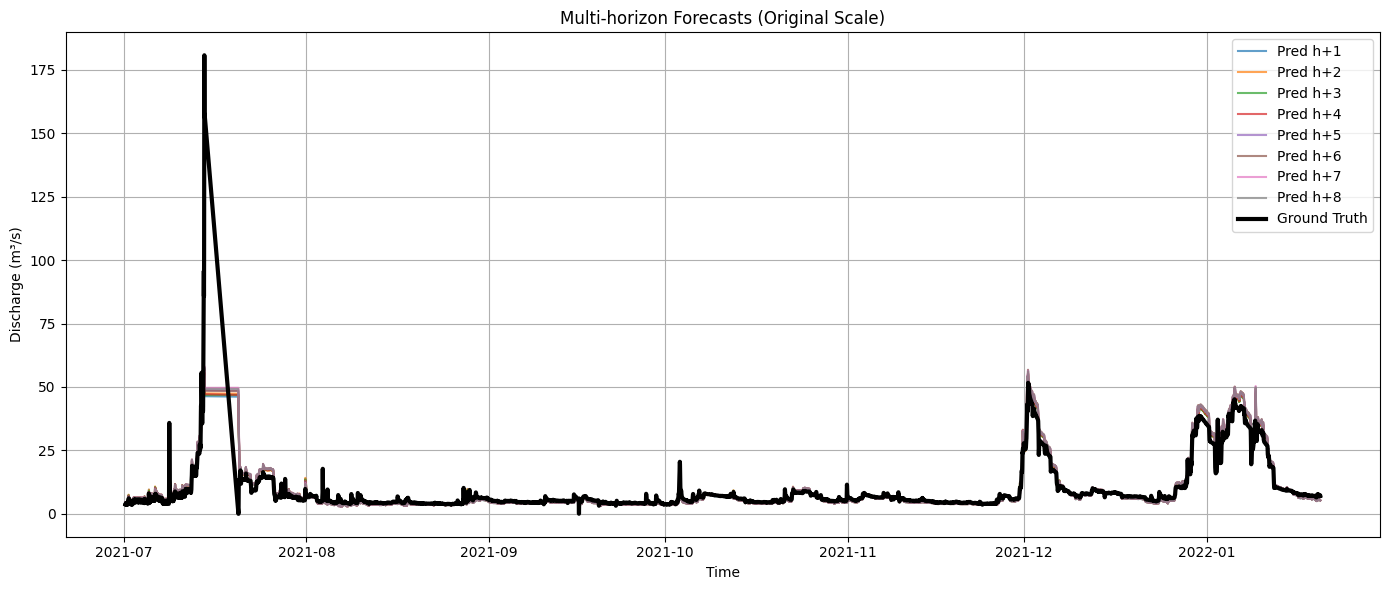

In [ ]:
plt.figure(figsize=(14, 6))

for h in range(H):
    plt.plot(
        time_index,
        y_pred_real[:, h, 0],
        label=f"Pred h+{h+1}",
        alpha=0.7
    )

plt.plot(
    time_index,
    y_true_real[:, 0, 0],
    color="black",
    linewidth=3,
    label="Ground Truth"
)

plt.legend()
plt.title("Multi-horizon Forecasts (Original Scale)")
plt.ylabel("Discharge (m³/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

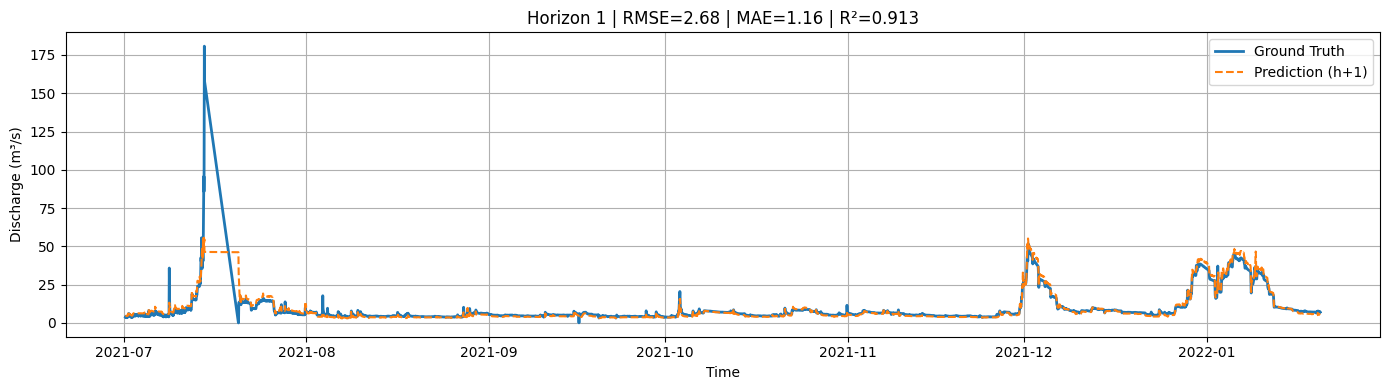

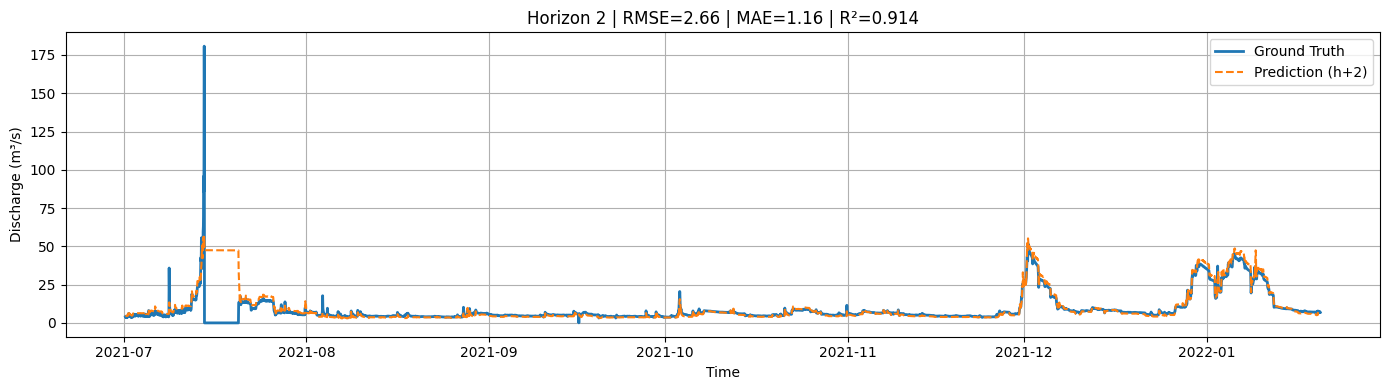

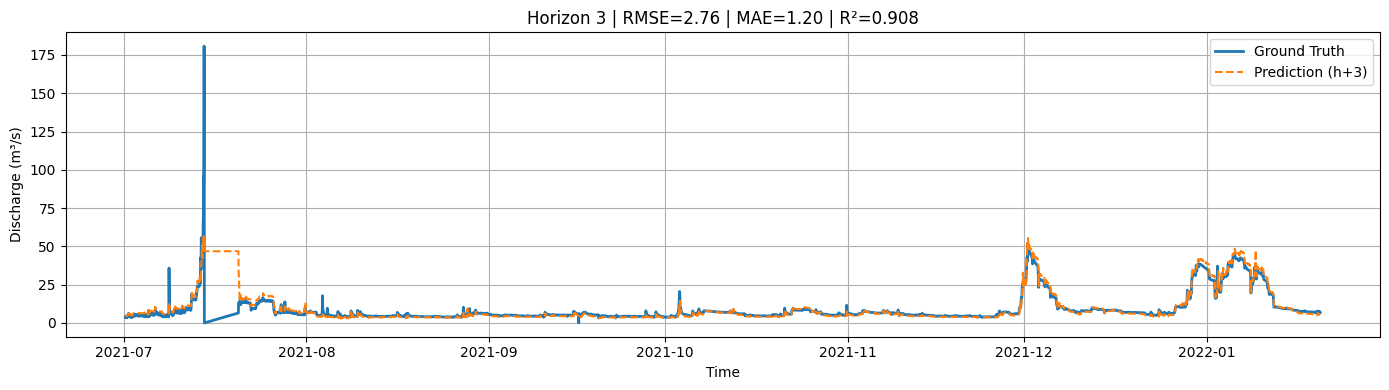

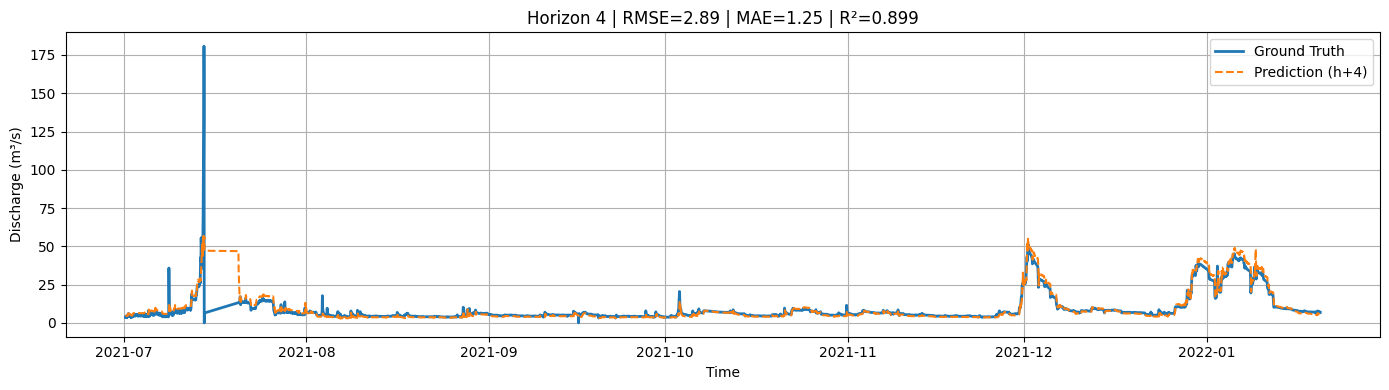

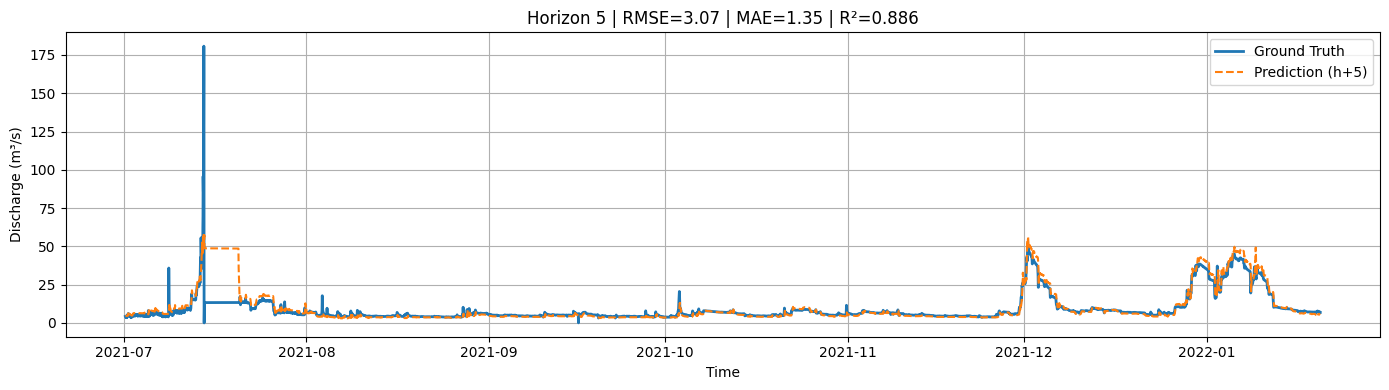

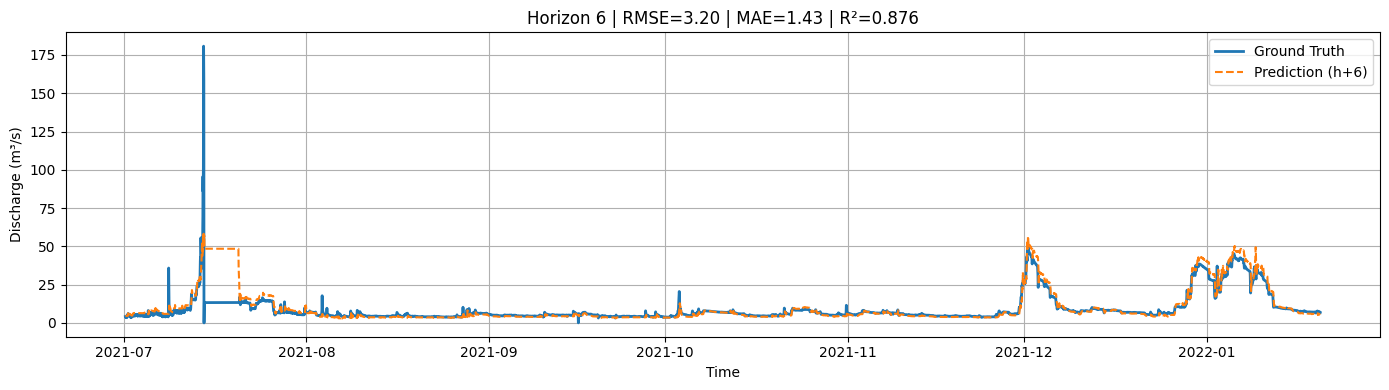

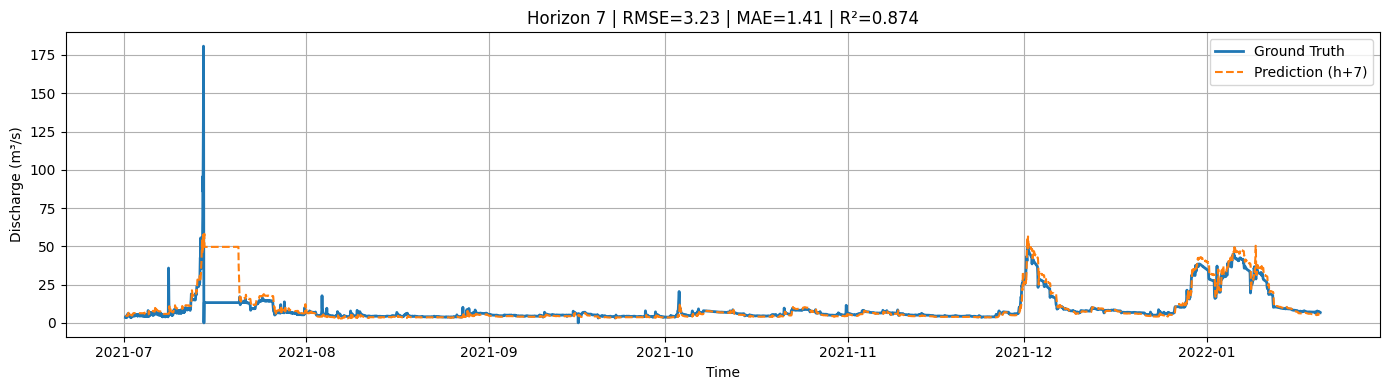

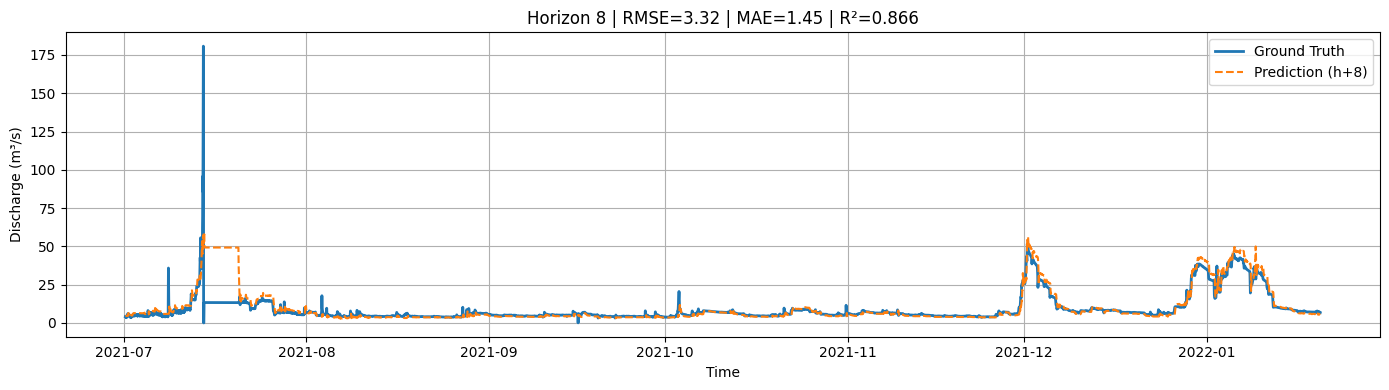

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

H = y_true_real.shape[1]

for h in range(H):
    y_t = y_true_real[:, h, 0]
    y_p = y_pred_real[:, h, 0]

    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    r2   = r2_score(y_t, y_p)

    plt.figure(figsize=(14, 4))
    plt.plot(time_index, y_t, label="Ground Truth", linewidth=2)
    plt.plot(time_index, y_p, label=f"Prediction (h+{h+1})", linestyle="--")

    plt.title(
        f"Horizon {h+1} | "
        f"RMSE={rmse:.2f} | "
        f"MAE={mae:.2f} | "
        f"R²={r2:.3f}"
    )

    plt.xlabel("Time")
    plt.ylabel("Discharge (m³/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

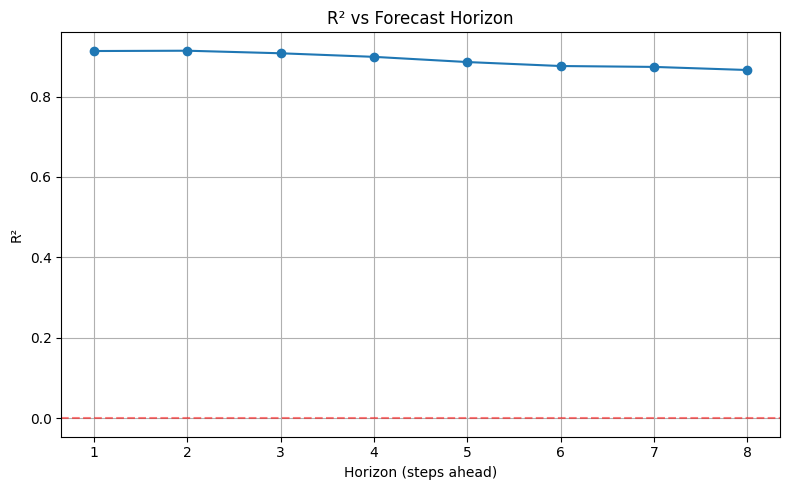

In [ ]:
import matplotlib.pyplot as plt

horizons = range(1, H+1)

plt.figure(figsize=(8, 5))
plt.plot(horizons, r2_per_h, marker="o")
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.title("R² vs Forecast Horizon")
plt.xlabel("Horizon (steps ahead)")
plt.ylabel("R²")
plt.grid(True)
plt.tight_layout()
plt.show()

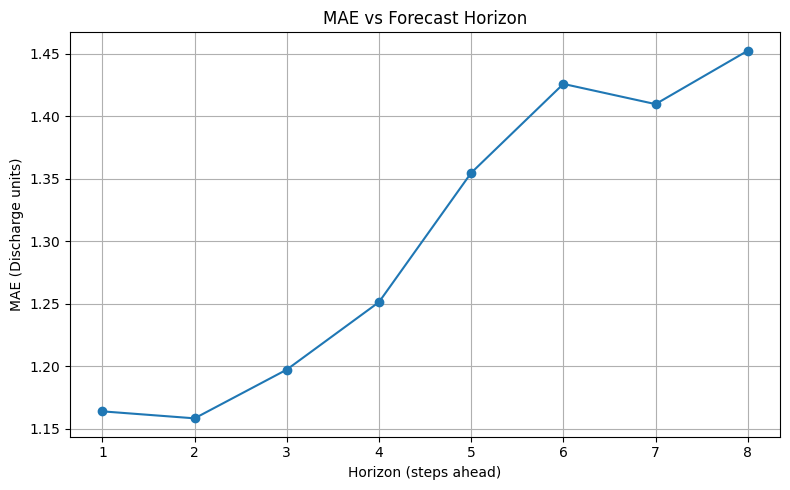

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(horizons, mae_per_h, marker="o")
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Horizon (steps ahead)")
plt.ylabel("MAE (Discharge units)")
plt.grid(True)
plt.tight_layout()
plt.show()

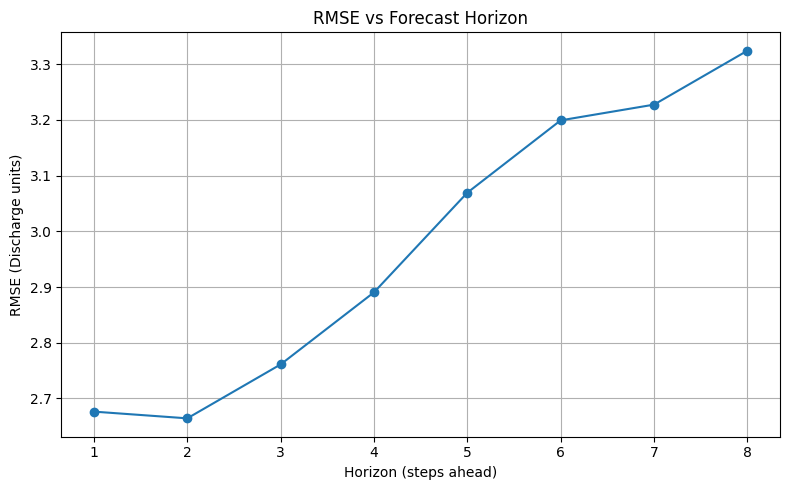

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(horizons, rmse_per_h, marker="o")
plt.title("RMSE vs Forecast Horizon")
plt.xlabel("Horizon (steps ahead)")
plt.ylabel("RMSE (Discharge units)")
plt.grid(True)
plt.tight_layout()
plt.show()

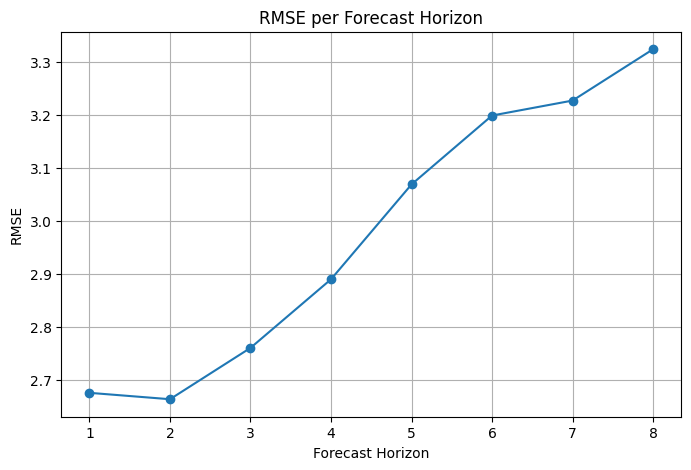

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, H+1), rmse_per_h, marker='o')
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.title("RMSE per Forecast Horizon")
plt.grid(True)
plt.show()

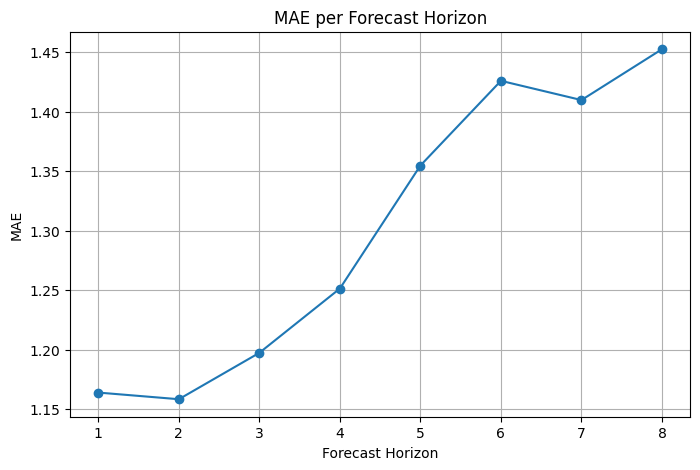

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, H+1), mae_per_h, marker='o')
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("MAE per Forecast Horizon")
plt.grid(True)
plt.show()

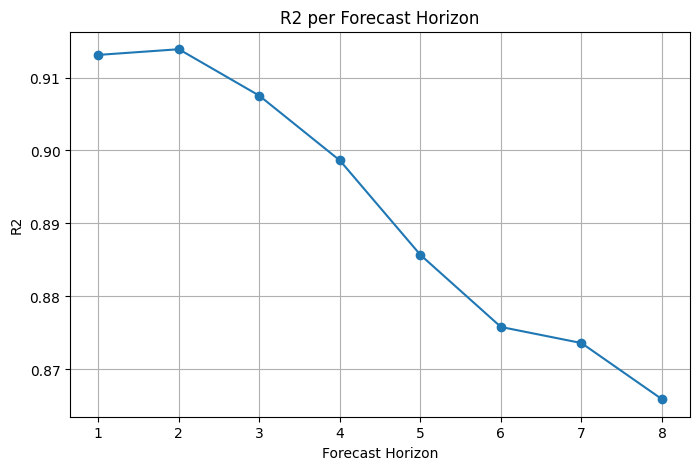

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, H+1), r2_per_h, marker='o')
plt.xlabel("Forecast Horizon")
plt.ylabel("R2")
plt.title("R2 per Forecast Horizon")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_horizon_only(
    timestamp,
    full_target_series,
    y_test_real,
    y_pred_real,
    lookback,
    horizon,
    test_start_idx,
    y_min=None,
    y_max=None,
    save_dir=None
):
    """
    Plot ONLY the horizon forecast (all steps) vs corresponding ground truth
    for a given timestamp.

    timestamp: pandas.Timestamp of the current sequence (the point at which prediction starts)
    full_target_series: full target series (original scale)
    y_test_real: test target sequences (N, H, 1)
    y_pred_real: predicted sequences (N, H, 1)
    lookback: number of past steps used
    horizon: forecast horizon (H)
    test_start_idx: index in full series where test set starts
    y_min, y_max: fixed y-axis
    save_dir: optional directory to save figure
    """

    # Locate the timestamp in full series
    t0 = full_target_series.index.get_loc(timestamp)

    # Compute index in test sequences
    i = t0 - test_start_idx - lookback
    if i < 0 or i >= len(y_test_real):
        raise ValueError("Timestamp not valid for test sequences")

    # Create future time index for horizon
    freq = pd.infer_freq(full_target_series.index)
    if freq is None:
        freq = full_target_series.index[1] - full_target_series.index[0]

    idx_future = pd.date_range(start=timestamp + freq, periods=horizon, freq=freq)

    # True and predicted horizon values
    true_future = y_test_real[i, :, 0]
    pred_future = y_pred_real[i, :, 0]

    plt.figure(figsize=(10, 5))
    plt.plot(idx_future, true_future, marker='o', color='green', label='True Future')
    plt.plot(idx_future, pred_future, marker='x', color='red', linestyle='--', label='Forecast')
    plt.axvline(timestamp, color='black', linestyle=':', alpha=0.7, label='Forecast start')

    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)

    plt.title(f"Horizon Forecast starting at {timestamp}")
    plt.xlabel("Time")
    plt.ylabel("Target (original units)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_dir is None:
        plt.show()
    else:
        import os
        os.makedirs(save_dir, exist_ok=True)
        fname = os.path.join(save_dir, f"horizon_forecast_{timestamp}.png")
        plt.savefig(fname)
        plt.close()

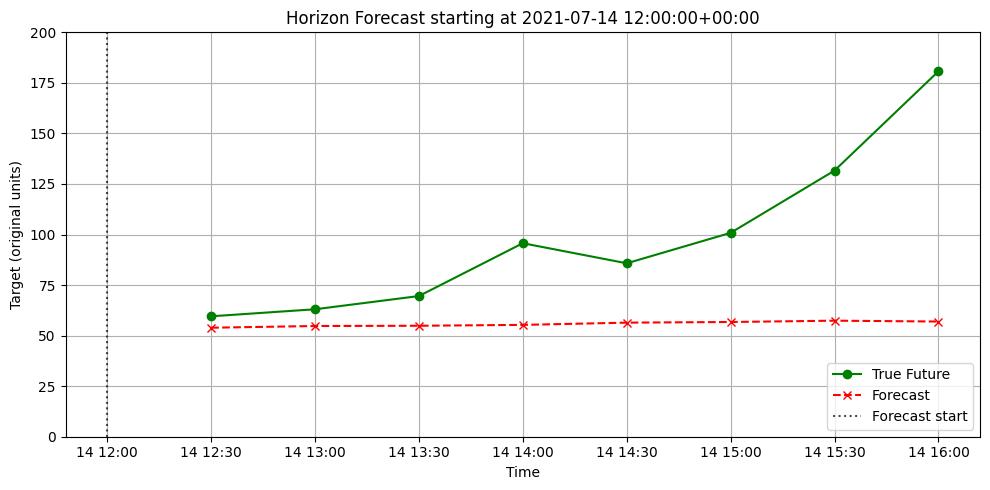

In [ ]:
# Define the target series from the full dataset
data_target_series = data[target_column]

# Determine the starting index of the test set within the full dataset
# The 'test' DataFrame has its own index, which is a subset of 'data.index'
# We need the integer position of the first element of 'test.index' within 'data.index'
test_start_idx = data.index.get_loc(test.index[0])

start_ts=pd.Timestamp("2021-07-14 05:00", tz='UTC')
end_ts=pd.Timestamp("2021-07-14 16:00", tz='UTC')
timestamp = pd.Timestamp("2021-07-14 12:00", tz='UTC')
horizon=H

plot_horizon_only(
    timestamp=timestamp, # Add the missing timestamp argument
    full_target_series=data_target_series,
    y_test_real=y_true_real,
    y_pred_real=y_pred_real,
    lookback=lookback,
    horizon=horizon,
    test_start_idx=test_start_idx,
    y_min=0,
    y_max=200
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_forecast_at_timestamp(
    timestamp,
    y_true_real,       # shape (N, H, T)
    y_pred_real,       # shape (N, H, T)
    test_timestamps,   # DatetimeIndex or array of timestamps, length N
    target_col=0,      # which T to visualize (default first variable)
    lookback=12,
    horizon=8,
    freq=None,         # e.g. 'h', 'D', 'MS' — inferred if None
):
    """
    Plot the lookback window, ground truth, and forecast for a given timestamp.

    Parameters
    ----------
    timestamp       : str or pd.Timestamp — the anchor point to inspect
    y_true_real     : np.ndarray of shape (N, H, T) — inverse-scaled ground truth
    y_pred_real     : np.ndarray of shape (N, H, T) — inverse-scaled predictions
    test_timestamps : array-like of timestamps, length N (one per sample)
    target_col      : int — which variable to plot when T > 1
    lookback        : int — number of past steps to show before the anchor
    horizon         : int — number of forecast steps (should match H)
    freq            : str — pandas freq string; inferred from timestamps if None
    """
    test_timestamps = pd.DatetimeIndex(test_timestamps)
    ts = pd.Timestamp(timestamp)

    # --- Find the sample index whose anchor timestamp matches ---
    matches = np.where(test_timestamps == ts)[0]
    if len(matches) == 0:
        available = test_timestamps[:5].tolist()
        raise ValueError(
            f"Timestamp '{ts}' not found in test_timestamps.\n"
            f"First few available: {available}"
        )
    idx = matches[0]

    # --- Infer frequency ---
    if freq is None:
        inferred = pd.infer_freq(test_timestamps)
        freq = inferred if inferred else 'h'

    # --- Build the lookback window from preceding samples ---
    # Each sample i has ground truth for horizon steps starting at test_timestamps[i]
    # For lookback, collect the single-step truth from the `lookback` samples before idx
    lookback_start = idx - lookback
    if lookback_start < 0:
        print(f"Warning: only {idx} lookback steps available (requested {lookback}).")
        lookback_start = 0

    # One ground-truth value per past sample (step 0 of each sample = its anchor value)
    lookback_values = y_true_real[lookback_start:idx, 0, target_col]
    lookback_times  = test_timestamps[lookback_start:idx]

    # --- Current anchor ---
    anchor_value = y_true_real[idx, 0, target_col]
    anchor_time  = ts

    # --- Ground truth for the full horizon at this sample ---
    gt_horizon_values = y_true_real[idx, :horizon, target_col]
    gt_horizon_times  = pd.date_range(start=ts, periods=horizon, freq=freq)

    # --- Predictions for the full horizon at this sample ---
    pred_horizon_values = y_pred_real[idx, :horizon, target_col]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 5))

    # Lookback
    ax.plot(lookback_times, lookback_values,
            color='steelblue', lw=2, marker='o', ms=4, label='Lookback (past truth)')

    # Connector from last lookback point to anchor
    if len(lookback_times) > 0:
        ax.plot([lookback_times[-1], anchor_time],
                [lookback_values[-1], anchor_value],
                color='steelblue', lw=2)

    # Ground truth over horizon
    ax.plot(gt_horizon_times, gt_horizon_values,
            color='seagreen', lw=2, marker='o', ms=4, label='Ground truth (horizon)')

    # Forecast
    ax.plot(gt_horizon_times, pred_horizon_values,
            color='tomato', lw=2, marker='x', ms=6, ls='--', label='Forecast')

    # Anchor marker
    ax.axvline(anchor_time, color='gray', ls=':', lw=1.5, label=f'Anchor: {ts}')
    ax.scatter([anchor_time], [anchor_value], color='gold', zorder=5, s=80, edgecolors='k')

    plt.ylim(0, 50)

    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    fig.autofmt_xdate(rotation=30)
    ax.set_title(f'Forecast at {ts}  |  Lookback={lookback}  Horizon={horizon}', fontsize=13)
    ax.set_xlabel('Time')
    ax.set_ylabel('Value' if target_col == 0 else f'Variable {target_col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Summary table ---
    summary = pd.DataFrame({
        'time':       gt_horizon_times,
        'truth':      gt_horizon_values,
        'forecast':   pred_horizon_values,
        'error':      pred_horizon_values - gt_horizon_values,
        'abs_error':  np.abs(pred_horizon_values - gt_horizon_values),
    }).set_index('time')
    print(summary.to_string())
    return summary

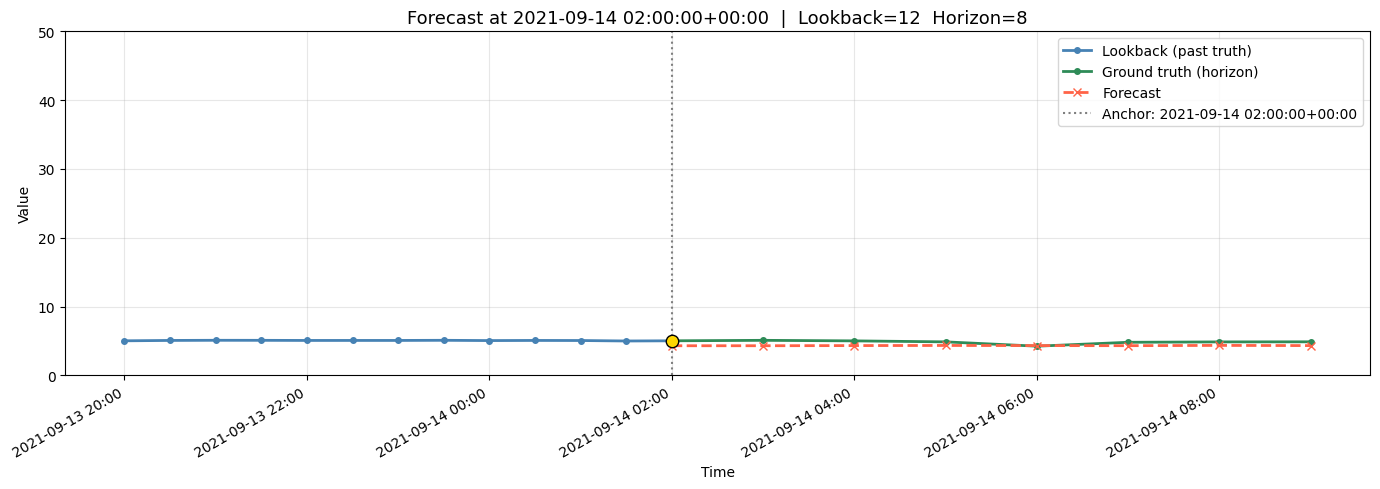

                              truth  forecast     error  abs_error
time                                                              
2021-09-14 02:00:00+00:00  5.036667  4.318550 -0.718117   0.718117
2021-09-14 03:00:00+00:00  5.106000  4.320759 -0.785241   0.785241
2021-09-14 04:00:00+00:00  5.026000  4.342227 -0.683774   0.683774
2021-09-14 05:00:00+00:00  4.882500  4.360079 -0.522421   0.522421
2021-09-14 06:00:00+00:00  4.256000  4.341340  0.085340   0.085340
2021-09-14 07:00:00+00:00  4.822000  4.328996 -0.493004   0.493004
2021-09-14 08:00:00+00:00  4.876667  4.368223 -0.508444   0.508444
2021-09-14 09:00:00+00:00  4.890000  4.340163 -0.549837   0.549837


In [ ]:
summary = plot_forecast_at_timestamp(
    timestamp=pd.Timestamp("2021-09-14 02:00", tz='UTC'),
    y_true_real=y_true_real,
    y_pred_real=y_pred_real,
    test_timestamps=test.index,   # or your timestamps array
    target_col=0,                    # change if T > 1
    lookback=12,
    horizon=8
)

## Confidence Intervals

In [ ]:
import torch
import numpy as np

def enable_dropout(model):
    """Keep dropout active during inference (MC Dropout)."""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def mc_dropout_inference(model, test_loader, n_runs=50, device='cpu'):
    """
    Run inference n_runs times with dropout active.
    Returns:
        y_pred_ensemble : (n_runs, N, H, n_targets)
        y_true          : (N, H, n_targets)
    """
    model.eval()           # freeze BN, etc.
    enable_dropout(model)  # but re-enable dropout only

    all_runs = []

    for run in range(n_runs):
        preds_run, targets_run = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                preds = model(X_batch)                    # (B, H, n_targets)
                preds_run.append(preds.cpu().numpy())
                if run == 0:
                    targets_run.append(y_batch.numpy())   # only need truth once

        all_runs.append(np.concatenate(preds_run, axis=0))   # (N, H, n_targets)
        if run == 0:
            y_true_scaled = np.concatenate(targets_run, axis=0)  # (N, H, n_targets)

    y_pred_ensemble_scaled = np.stack(all_runs, axis=0)  # (n_runs, N, H, n_targets)

    return y_pred_ensemble_scaled, y_true_scaled




In [ ]:
N_RUNS = 50   # 30–100 is typical; more = smoother bands

y_pred_ensemble_scaled, y_true_scaled = mc_dropout_inference(
    model=best_model,
    test_loader=test_loader,
    n_runs=N_RUNS,
    device='cpu',   # or 'cuda'
)

print(f"Ensemble shape : {y_pred_ensemble_scaled.shape}")   # (50, N, H, 1)
print(f"True shape     : {y_true_scaled.shape}")            # (N, H, 1)

Ensemble shape : (50, 9432, 8, 1)
True shape     : (9432, 8, 1)


In [ ]:
N, H, T = y_true_scaled.shape
n_runs   = y_pred_ensemble_scaled.shape[0]

# Inverse-scale ground truth  →  (N, H, T)
y_true_real = y_scaler.inverse_transform(
    y_true_scaled.reshape(-1, T)
).reshape(N, H, T)

# Inverse-scale each run  →  (n_runs, N, H, T)
y_pred_ensemble_real = np.stack([
    y_scaler.inverse_transform(
        y_pred_ensemble_scaled[r].reshape(-1, T)
    ).reshape(N, H, T)
    for r in range(n_runs)
], axis=0)

print(f"y_true_real shape         : {y_true_real.shape}")          # (N, H, 1)
print(f"y_pred_ensemble_real shape: {y_pred_ensemble_real.shape}") # (50, N, H, 1)

y_true_real shape         : (9432, 8, 1)
y_pred_ensemble_real shape: (50, 9432, 8, 1)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_forecast_at_timestamp(
    timestamp,
    y_true_real,           # (N, H, 1)
    y_pred_ensemble_real,  # (n_runs, N, H, 1)
    test_timestamps,       # DatetimeIndex, length N
    lookback=12,
    horizon=8,
    freq=None,
    quantiles='all',       # 'all' | '80' | '90' | '50'
    show_runs=True,        # overlay faint individual MC runs
):
    test_timestamps = pd.DatetimeIndex(test_timestamps)
    ts = pd.Timestamp(timestamp)

    # ── 1. Find sample index ──────────────────────────────────────────────────
    matches = np.where(test_timestamps == ts)[0]
    if len(matches) == 0:
        closest = test_timestamps[np.argmin(np.abs(test_timestamps - ts))]
        raise ValueError(
            f"Timestamp '{ts}' not found.\n"
            f"Closest available: {closest}\n"
            f"Range: {test_timestamps[0]}  →  {test_timestamps[-1]}"
        )
    idx = matches[0]

    # ── 2. Infer frequency ────────────────────────────────────────────────────
    if freq is None:
        freq = pd.infer_freq(test_timestamps) or 'h'

    # ── 3. Lookback window ────────────────────────────────────────────────────
    lb_start = max(0, idx - lookback)
    lookback_times  = test_timestamps[lb_start:idx]
    lookback_values = y_true_real[lb_start:idx, 0, 0]

    # ── 4. Anchor ─────────────────────────────────────────────────────────────
    anchor_value = float(y_true_real[idx, 0, 0])

    # ── 5. Horizon times & ground truth ──────────────────────────────────────
    horizon_times = pd.date_range(start=ts, periods=horizon, freq=freq)
    gt_values     = y_true_real[idx, :horizon, 0]       # (H,)

    # ── 6. MC Dropout statistics at this sample ───────────────────────────────
    run_preds   = y_pred_ensemble_real[:, idx, :horizon, 0]  # (n_runs, H)
    n_runs      = run_preds.shape[0]
    pred_median = np.median(run_preds, axis=0)               # (H,)
    pred_mean   = run_preds.mean(axis=0)

    q = {k: np.percentile(run_preds, v, axis=0) for k, v in {
        'q05': 5, 'q10': 10, 'q25': 25,
        'q75': 75, 'q90': 90, 'q95': 95,
    }.items()}

    # ── 7. Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 5))

    # Lookback → anchor
    ax.plot(list(lookback_times) + [ts],
            list(lookback_values) + [anchor_value],
            color='steelblue', lw=2, marker='o', ms=4,
            label=f'Lookback ({len(lookback_times)} steps)')

    ax.axvline(ts, color='gray', ls=':', lw=1.5, alpha=0.7)

    # Ground truth horizon
    ax.plot([ts] + list(horizon_times),
            [anchor_value] + list(gt_values),
            color='seagreen', lw=2.5, marker='o', ms=5,
            label='Ground truth')

    # Faint individual MC runs
    if show_runs:
        for r in range(n_runs):
            ax.plot([ts] + list(horizon_times),
                    [anchor_value] + list(run_preds[r]),
                    color='tomato', lw=0.5, alpha=max(0.05, 1.5 / n_runs))

    # Confidence bands
    band_configs = {
        '90':  [('q05', 'q95', 0.15, '90% CI  (Q5–Q95)')],
        '80':  [('q10', 'q90', 0.22, '80% CI  (Q10–Q90)')],
        '50':  [('q25', 'q75', 0.38, '50% CI  (Q25–Q75)')],
        'all': [
            ('q05', 'q95', 0.10, '90% CI  (Q5–Q95)'),
            ('q10', 'q90', 0.17, '80% CI  (Q10–Q90)'),
            ('q25', 'q75', 0.28, '50% CI  (Q25–Q75)'),
        ],
    }
    for lo_k, hi_k, alpha, label in band_configs.get(str(quantiles), band_configs['all']):
        ax.fill_between(horizon_times, q[lo_k], q[hi_k],
                        color='tomato', alpha=alpha, label=label)

    # Median forecast
    ax.plot([ts] + list(horizon_times),
            [anchor_value] + list(pred_median),
            color='tomato', lw=2.5, marker='x', ms=7, ls='--',
            label=f'MC median  ({n_runs} runs)')

    # Anchor dot
    ax.scatter([ts], [anchor_value], color='gold', s=120,
               zorder=6, edgecolors='k', label=f'Anchor: {ts}')

    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
    ax.set_title(
        f'MC Dropout Forecast  @  {ts}   |   '
        f'lookback={len(lookback_times)}   horizon={horizon}   MC runs={n_runs}',
        fontsize=13, pad=12
    )
    ax.set_xlabel('Time')
    ax.set_ylabel('Value (original scale)')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # ── 8. Summary table ──────────────────────────────────────────────────────
    summary = pd.DataFrame({
        'ground_truth': gt_values,
        'mc_median':    pred_median,
        'mc_mean':      pred_mean,
        'mc_std':       run_preds.std(axis=0),
        'error':        pred_median - gt_values,
        'abs_error':    np.abs(pred_median - gt_values),
        'q05': q['q05'], 'q25': q['q25'],
        'q75': q['q75'], 'q95': q['q95'],
    }, index=horizon_times)
    summary.index.name = 'time'

    print(f"\n{'─'*75}")
    print(f"  MC Dropout forecast summary at {ts}  ({n_runs} runs)")
    print(f"{'─'*75}")
    print(summary.to_string(float_format='{:.4f}'.format))
    print(f"{'─'*75}")
    print(f"  MAE  (median) = {summary['abs_error'].mean():.4f}")
    print(f"  RMSE (median) = {np.sqrt((summary['error']**2).mean()):.4f}")
    print(f"{'─'*75}\n")

    return summary

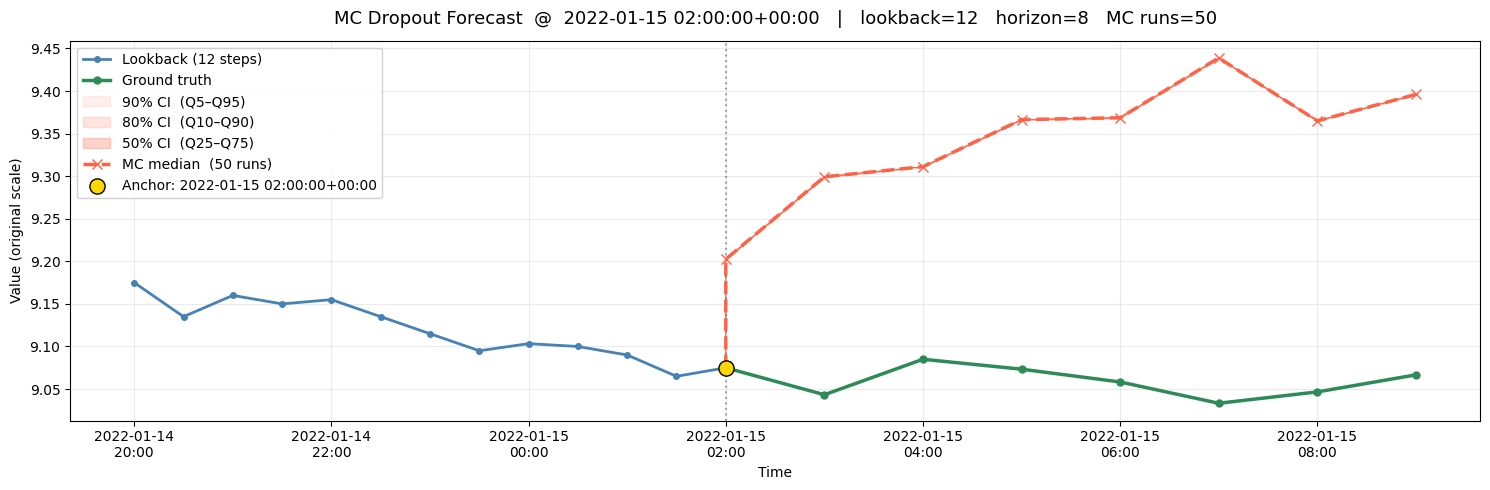


───────────────────────────────────────────────────────────────────────────
  MC Dropout forecast summary at 2022-01-15 02:00:00+00:00  (50 runs)
───────────────────────────────────────────────────────────────────────────
                           ground_truth  mc_median  mc_mean  mc_std  error  abs_error    q05    q25    q75    q95
time                                                                                                             
2022-01-15 02:00:00+00:00        9.0750     9.2025   9.2025  0.0000 0.1275     0.1275 9.2025 9.2025 9.2025 9.2025
2022-01-15 03:00:00+00:00        9.0433     9.2993   9.2993  0.0000 0.2560     0.2560 9.2993 9.2993 9.2993 9.2993
2022-01-15 04:00:00+00:00        9.0850     9.3112   9.3112  0.0000 0.2262     0.2262 9.3112 9.3112 9.3112 9.3112
2022-01-15 05:00:00+00:00        9.0733     9.3664   9.3664  0.0000 0.2931     0.2931 9.3664 9.3664 9.3664 9.3664
2022-01-15 06:00:00+00:00        9.0583     9.3686   9.3686  0.0000 0.3103     0.3103 9.3686 

In [ ]:
summary = plot_forecast_at_timestamp(
    timestamp=pd.Timestamp("2022-01-15 02:00", tz='UTC'),
    y_true_real=y_true_real,
    y_pred_ensemble_real=y_pred_ensemble_real,
    test_timestamps=test.index,
    lookback=12,
    horizon=8,
    freq='h',
    quantiles='all',    # 'all' | '80' | '90' | '50'
    show_runs=True,
)

## Linear regression

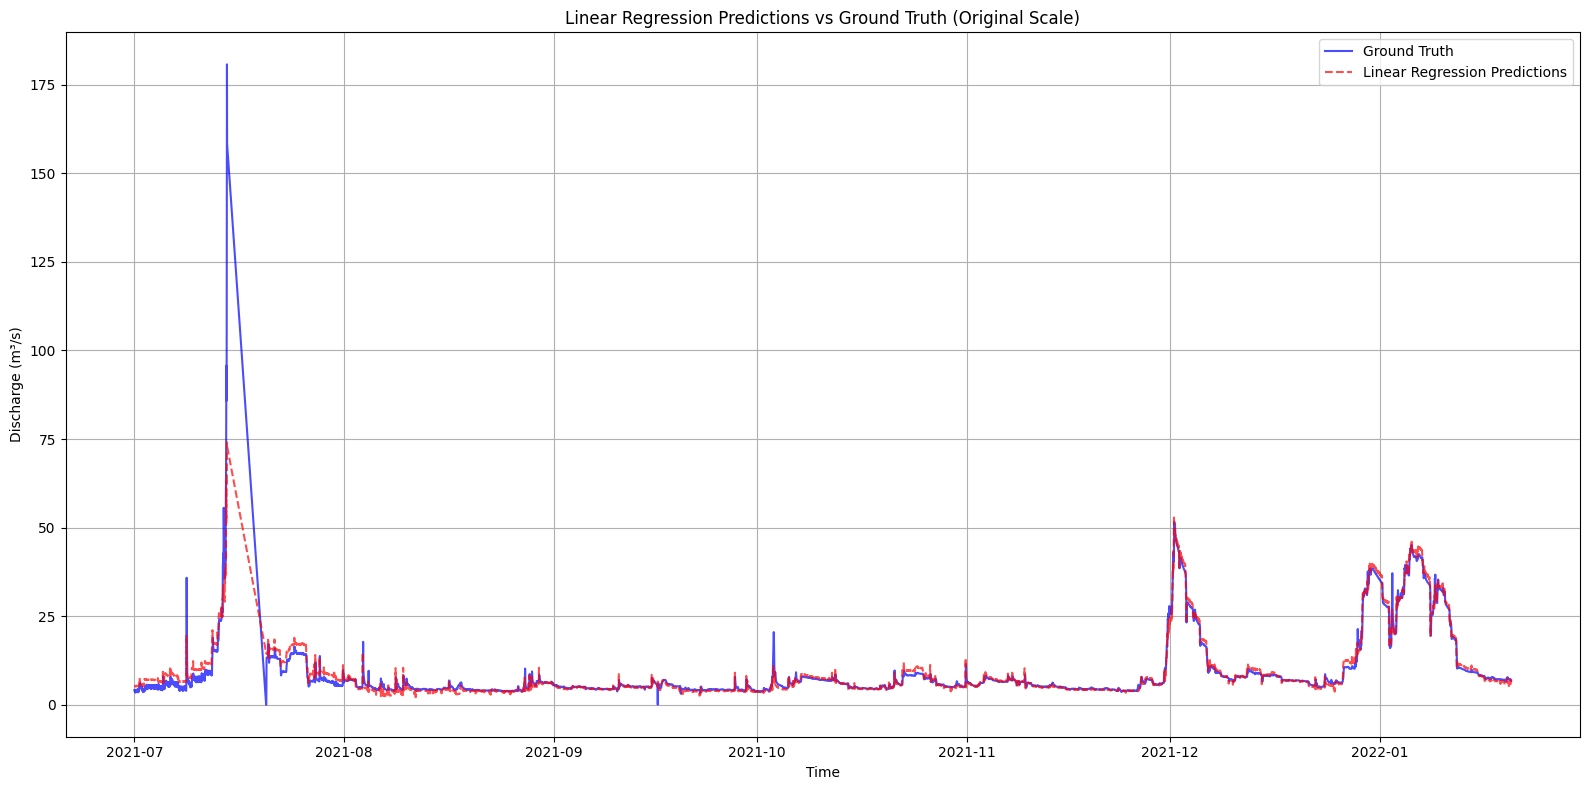


Linear Regression Model Performance:
RMSE: 2.2681
MAE : 0.8972
R2  : 0.9375


In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the scaled training data
# y_train_scaled is a DataFrame with shape (samples, 1), which is suitable for sklearn
linear_model.fit(X_train_scaled, y_train_scaled)

# Make predictions on the scaled test data
linear_predictions_scaled = linear_model.predict(X_test_scaled)

# Inverse transform the scaled predictions and true values to the original scale
linear_predictions_real = y_scaler.inverse_transform(linear_predictions_scaled)
y_test_real_linear = y_scaler.inverse_transform(y_test_scaled)

# Flatten the arrays for plotting (they should be 1D per target for clear plotting)
linear_predictions_real = linear_predictions_real.flatten()
y_test_real_linear = y_test_real_linear.flatten()

# Get the time index for the test set (from X_test_scaled)
time_index_test = X_test_scaled.index

# Create a DataFrame for easy plotting
df_linear_results = pd.DataFrame({
    'Ground Truth': y_test_real_linear,
    'Linear Regression Predictions': linear_predictions_real
}, index=time_index_test)

# Plotting the predictions against ground truth
plt.figure(figsize=(16, 8))
plt.plot(df_linear_results.index, df_linear_results['Ground Truth'], label='Ground Truth', color='blue', alpha=0.7)
plt.plot(df_linear_results.index, df_linear_results['Linear Regression Predictions'], label='Linear Regression Predictions', color='red', linestyle='--', alpha=0.7)
plt.title('Linear Regression Predictions vs Ground Truth (Original Scale)')
plt.xlabel('Time')
plt.ylabel('Discharge (m³/s)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate and print metrics
rmse_lr = np.sqrt(mean_squared_error(y_test_real_linear, linear_predictions_real))
mae_lr  = mean_absolute_error(y_test_real_linear, linear_predictions_real)
r2_lr   = r2_score(y_test_real_linear, linear_predictions_real)

print("\nLinear Regression Model Performance:")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE : {mae_lr:.4f}")
print(f"R2  : {r2_lr:.4f}")

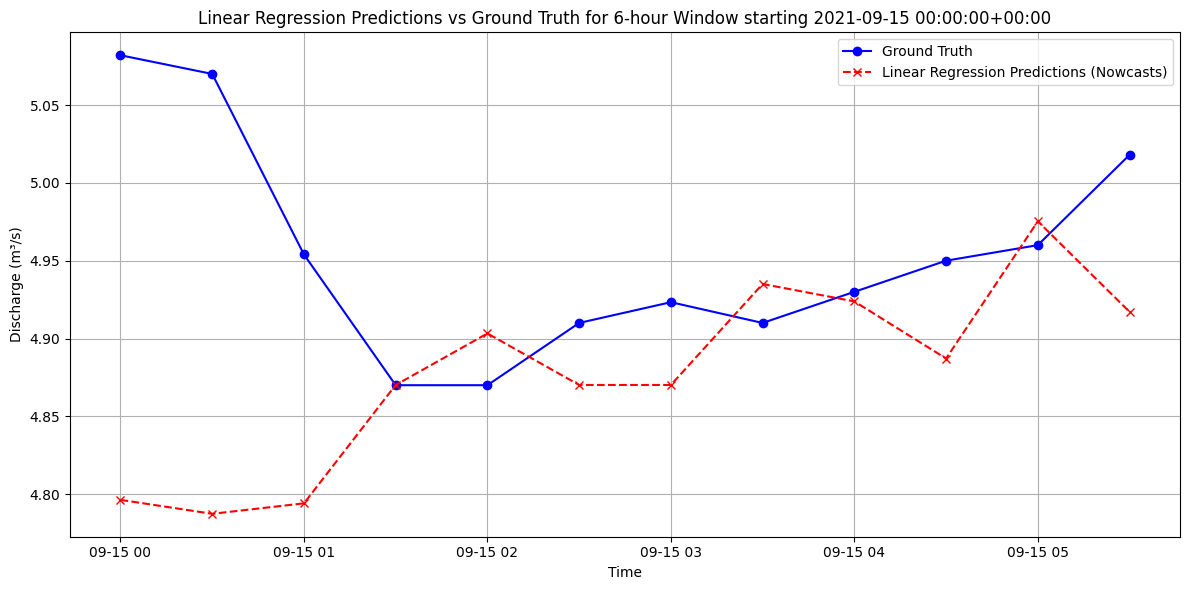


Linear Regression Performance for 6-hour Window:
Start Timestamp: 2021-09-15 00:00:00+00:00
End Timestamp: 2021-09-15 05:30:00+00:00
RMSE: 0.1315
MAE : 0.0887
R2  : -2.8813


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define the starting timestamp for the 6-hour prediction window
timestamp_to_predict_from = pd.Timestamp("2021-09-15 00:00", tz='UTC') # Example timestamp, modify as needed
forecast_window_hours = 6

# Find the index of the starting timestamp in the test set
if timestamp_to_predict_from not in X_test_scaled.index:
    print(f"Warning: The timestamp {timestamp_to_predict_from} is not directly in the test set index. Finding closest.")
    # Find the closest timestamp if exact match not found
    closest_idx = X_test_scaled.index.get_indexer([timestamp_to_predict_from], method='nearest')[0]
    timestamp_to_predict_from = X_test_scaled.index[closest_idx]
    print(f"Using closest timestamp: {timestamp_to_predict_from}")

start_idx_loc = X_test_scaled.index.get_loc(timestamp_to_predict_from)

# Determine the number of time steps for the 6-hour window
# Assuming 30-minute intervals, 6 hours is 12 steps (6 * 60 / 30)
num_steps_in_window = forecast_window_hours * 2 # 2 steps per hour for 30min data

# Get the features and true target values for the 6-hour window
end_idx_loc = start_idx_loc + num_steps_in_window

# Ensure the window does not go out of bounds of the test set
if end_idx_loc > len(X_test_scaled):
    end_idx_loc = len(X_test_scaled)
    num_steps_in_window = end_idx_loc - start_idx_loc
    print(f"Adjusted window to {num_steps_in_window} steps due to end of test data.")


window_X_scaled = X_test_scaled.iloc[start_idx_loc:end_idx_loc]
window_y_scaled = y_test_scaled.iloc[start_idx_loc:end_idx_loc]
window_time_index = X_test_scaled.index[start_idx_loc:end_idx_loc]

if window_X_scaled.empty:
    print(f"No data available for the specified window starting at {timestamp_to_predict_from}")
else:
    # Make predictions using the linear regression model
    window_predictions_scaled = linear_model.predict(window_X_scaled)

    # Inverse transform to original scale
    window_predictions_real = y_scaler.inverse_transform(window_predictions_scaled).flatten()
    window_y_real = y_scaler.inverse_transform(window_y_scaled).flatten()

    # Create a DataFrame for easy plotting
    df_window_results = pd.DataFrame({
        'Ground Truth': window_y_real,
        'Linear Regression Predictions': window_predictions_real
    }, index=window_time_index)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(df_window_results.index, df_window_results['Ground Truth'], label='Ground Truth', color='blue', marker='o', linestyle='-')
    plt.plot(df_window_results.index, df_window_results['Linear Regression Predictions'], label='Linear Regression Predictions (Nowcasts)', color='red', marker='x', linestyle='--')
    plt.title(f'Linear Regression Predictions vs Ground Truth for {forecast_window_hours}-hour Window starting {timestamp_to_predict_from}')
    plt.xlabel('Time')
    plt.ylabel('Discharge (m³/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate metrics for this window
    rmse_window = np.sqrt(mean_squared_error(window_y_real, window_predictions_real))
    mae_window  = mean_absolute_error(window_y_real, window_predictions_real)
    r2_window   = r2_score(window_y_real, window_predictions_real)

    print(f"\nLinear Regression Performance for {forecast_window_hours}-hour Window:")
    print(f"Start Timestamp: {timestamp_to_predict_from}")
    print(f"End Timestamp: {window_time_index[-1]}")
    print(f"RMSE: {rmse_window:.4f}")
    print(f"MAE : {mae_window:.4f}")
    print(f"R2  : {r2_window:.4f}")